# Semaine 1 — Notebook 00
# Biais, précision, exactitude et intervalle de confiance

Ce notebook complète le notebook 01 en introduisant trois notions souvent confondues :

- le **biais** — une erreur systématique que la moyenne ne corrige pas ;
- la **précision** vs l'**exactitude** — deux qualités distinctes d'un capteur ;
- l'**intervalle de confiance** — comment traduire un écart-type en affirmation concrète.

Ces notions sont indispensables avant d'aborder les filtres de Kalman.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

true_position = 100.0  # m — position réelle du véhicule

---
## 1. Le biais — une erreur que la moyenne ne corrige pas

Dans le notebook précédent, le bruit était toujours centré sur zéro :

$$v \sim \mathcal{N}(0, \sigma^2)$$

Cela signifiait que le capteur se trompait parfois en plus, parfois en moins, mais **en moyenne il avait raison**.

Un capteur **biaisé** se trompe systématiquement dans la même direction :

$$z = x + b + v$$

avec :
- $b$ : le biais — une erreur constante, toujours présente ;
- $v$ : le bruit aléatoire habituel.

**Conséquence importante :** accumuler des mesures ne corrige pas le biais.  
Plus on mesure, plus on est certain... de la mauvaise valeur.

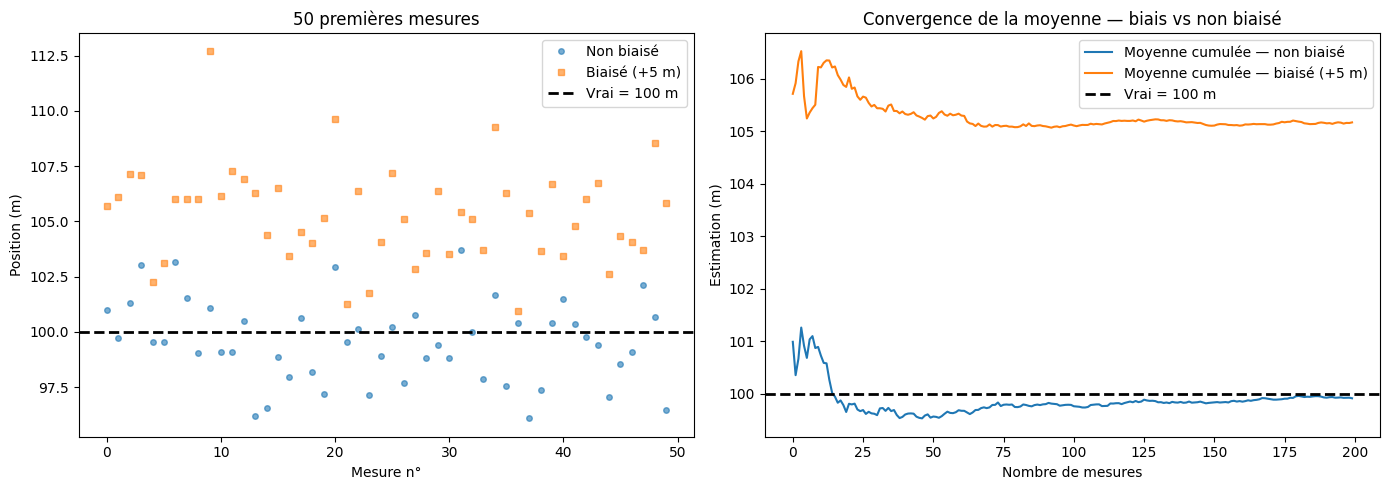

Capteur non biaisé — moyenne finale : 99.918 m
Capteur biaisé     — moyenne finale : 105.172 m

→ Avec 200 mesures, le capteur biaisé reste à 5.17 m de la vérité.
  Ajouter plus de mesures ne changera rien.


In [4]:
n = 200
sigma = 2.0
bias = 5.0  # le capteur surestime systématiquement de 5 m

# Capteur non biaisé
measurements_unbiased = true_position + np.random.normal(0, sigma, n)

# Capteur biaisé
measurements_biased = true_position + bias + np.random.normal(0, sigma, n)

# Moyenne cumulée des deux capteurs
cumul_unbiased = np.cumsum(measurements_unbiased) / np.arange(1, n + 1)
cumul_biased   = np.cumsum(measurements_biased)   / np.arange(1, n + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mesures brutes
ax = axes[0]
ax.plot(measurements_unbiased[:50], 'o', markersize=4, alpha=0.6, label='Non biaisé')
ax.plot(measurements_biased[:50],   's', markersize=4, alpha=0.6, label='Biaisé (+5 m)')
ax.axhline(true_position, linestyle='--', color='black', linewidth=2, label='Vrai = 100 m')
ax.set_xlabel('Mesure n°')
ax.set_ylabel('Position (m)')
ax.set_title('50 premières mesures')
ax.legend()

# Convergence de la moyenne cumulée
ax = axes[1]
ax.plot(cumul_unbiased, label='Moyenne cumulée — non biaisé')
ax.plot(cumul_biased,   label='Moyenne cumulée — biaisé (+5 m)')
ax.axhline(true_position, linestyle='--', color='black', linewidth=2, label='Vrai = 100 m')
ax.set_xlabel('Nombre de mesures')
ax.set_ylabel('Estimation (m)')
ax.set_title('Convergence de la moyenne — biais vs non biaisé')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Capteur non biaisé — moyenne finale : {cumul_unbiased[-1]:.3f} m")
print(f"Capteur biaisé     — moyenne finale : {cumul_biased[-1]:.3f} m")
print(f"\n→ Avec 200 mesures, le capteur biaisé reste à {abs(cumul_biased[-1] - true_position):.2f} m de la vérité.")
print(f"  Ajouter plus de mesures ne changera rien.")

### Pourquoi le biais est dangereux

Un capteur biaisé peut sembler fonctionner correctement si on ne compare pas à la vérité.  
Ses mesures sont stables, régulières, reproductibles — mais systématiquement fausses.

En navigation aérospatiale, un biais non détecté sur un gyroscope ou un accéléromètre  
entraîne une **dérive** de la trajectoire estimée qui s'accumule sans limite dans le temps.

**Comment le corriger ?**

- **Calibration** : mesurer le biais à l'arrêt et le soustraire
- **Fusion avec un capteur de référence** : le GPS corrige la dérive de l'IMU
- **Estimer le biais dans le filtre** : l'ajouter comme variable d'état (vu en Module 02)

---
## 2. Précision vs exactitude

Ces deux mots sont souvent utilisés comme synonymes dans le langage courant.  
En métrologie et en ingénierie, ils désignent deux qualités **complètement différentes**.

| Terme | Définition | Lié à |
|-------|-----------|-------|
| **Précision** | Les mesures sont groupées entre elles | Variance $\sigma^2$ |
| **Exactitude** | Les mesures sont proches de la vraie valeur | Biais $b$ |

Un capteur peut être :
- précis **et** exact → idéal
- précis **mais** inexact → biaisé, dangereux car difficile à détecter
- imprécis **mais** exact → bruité, corrigeable par moyennage
- imprécis **et** inexact → inutilisable

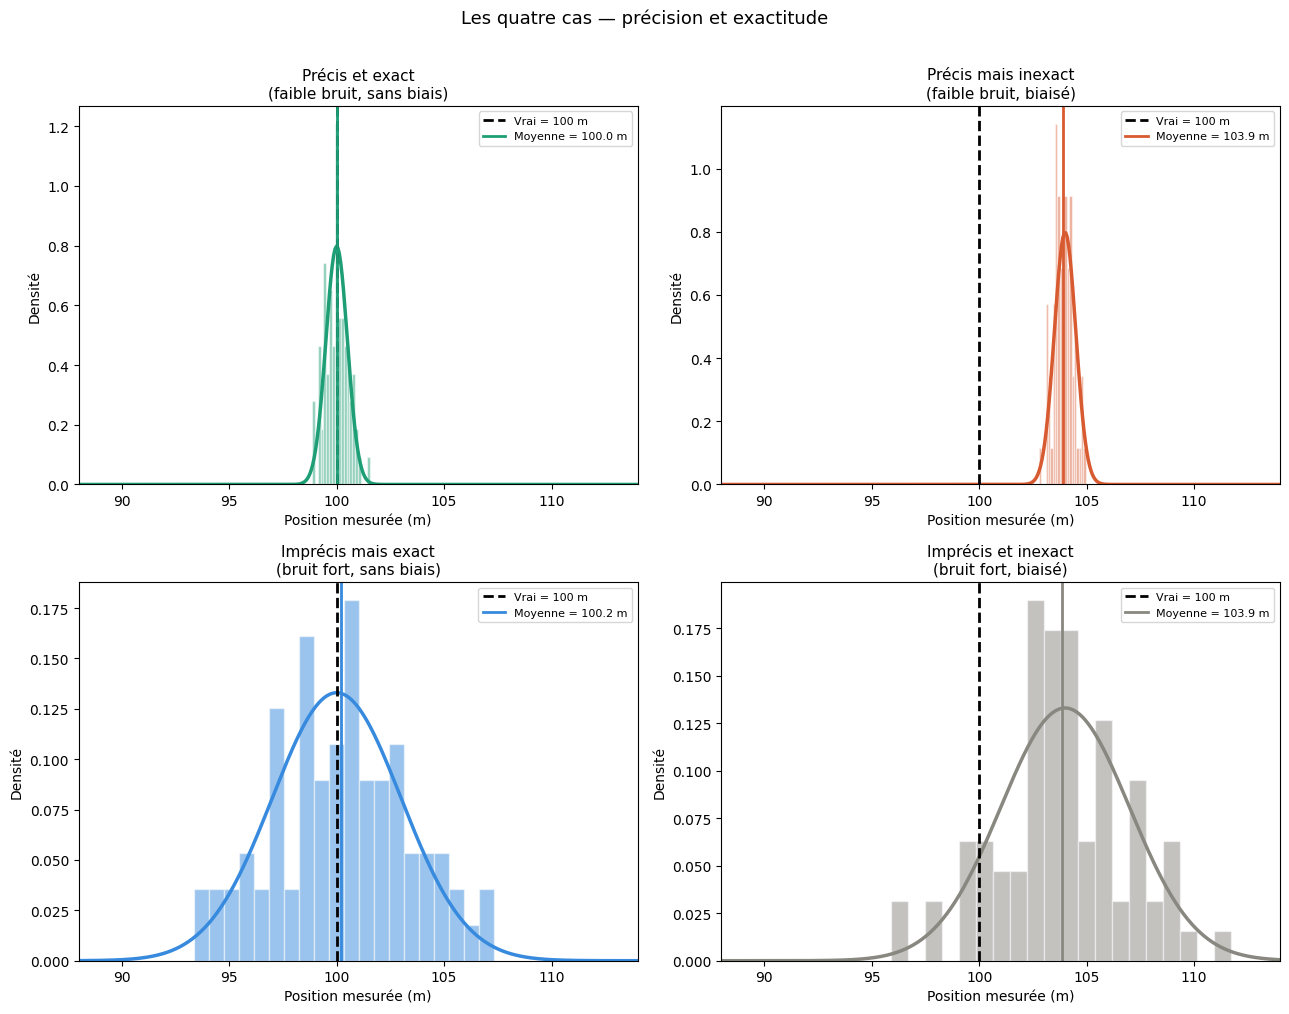

In [9]:
n_pts = 80

sensors = {
    'Précis et exact\n(faible bruit, sans biais)':    {'bias': 0.0, 'sigma': 0.5,  'color': '#1D9E75'},
    'Précis mais inexact\n(faible bruit, biaisé)':    {'bias': 4.0, 'sigma': 0.5,  'color': '#D85A30'},
    'Imprécis mais exact\n(bruit fort, sans biais)':  {'bias': 0.0, 'sigma': 3.0,  'color': '#378ADD'},
    'Imprécis et inexact\n(bruit fort, biaisé)':      {'bias': 4.0, 'sigma': 3.0,  'color': '#888780'},
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

x_range = np.linspace(88, 114, 400)

for ax, (title, params) in zip(axes, sensors.items()):
    b, s, c = params['bias'], params['sigma'], params['color']
    measurements = true_position + b + np.random.normal(0, s, n_pts)

    # Histogramme
    ax.hist(measurements, bins=20, density=True,
            color=c, alpha=0.5, edgecolor='white')

    # Courbe gaussienne théorique
    ax.plot(x_range, norm.pdf(x_range, true_position + b, s),
            color=c, linewidth=2.5)

    # Repères
    ax.axvline(true_position, color='black', linewidth=2,
               linestyle='--', label='Vrai = 100 m')
    ax.axvline(np.mean(measurements), color=c, linewidth=2,
               linestyle='-', label=f'Moyenne = {np.mean(measurements):.1f} m')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Position mesurée (m)')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.set_xlim(88, 114)

plt.suptitle('Les quatre cas — précision et exactitude', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Le cas le plus dangereux

**Précis mais inexact** est le cas le plus difficile à détecter en pratique.

Les mesures sont stables et reproductibles — l'opérateur a l'impression que tout va bien.  
Mais toutes les mesures sont décalées de la même façon.

Exemples réels :
- un gyroscope dont la température fait dériver le zéro
- un altimètre mal calé sur la pression de référence
- un GPS dont le récepteur introduit un délai constant

> **Règle à retenir :** un capteur précis n'est pas forcément fiable.  
> La précision mesure la **répétabilité**. L'exactitude mesure la **vérité**.

---
## 3. L'intervalle de confiance

L'écart-type $\sigma$ est un chiffre abstrait. L'**intervalle de confiance** le traduit en phrase concrète.

**Définition :** un intervalle de confiance à $p$% est l'intervalle $[\hat{x} - \delta, \hat{x} + \delta]$  
dans lequel la vraie valeur se trouve avec une probabilité de $p$%.

Pour une distribution gaussienne, les intervalles usuels sont :

| Niveau de confiance | Demi-largeur | Formule |
|--------------------|-------------|--------|
| 68 % | $1\sigma$ | $[\hat{x} - \sigma,\ \hat{x} + \sigma]$ |
| 95 % | $1.96\sigma$ | $[\hat{x} - 1.96\sigma,\ \hat{x} + 1.96\sigma]$ |
| 99 % | $2.58\sigma$ | $[\hat{x} - 2.58\sigma,\ \hat{x} + 2.58\sigma]$ |

**Exemple concret :**  
GPS avec $\hat{x} = 102$ m et $\sigma = 3$ m :

- Intervalle à 68 % : $[99\ \text{m},\ 105\ \text{m}]$
- Intervalle à 95 % : $[96.1\ \text{m},\ 107.9\ \text{m}]$

> *"Je suis sûr à 95 % que le drone est entre 96 m et 108 m."*

C'est ce langage que les ingénieurs et les systèmes embarqués utilisent.

In [13]:
gps_sigma = 3.0
gps_measurements = true_position + np.random.normal(0, gps_sigma, 200)
estimate = np.mean(gps_measurements)

# Intervalles de confiance
ci_68  = (estimate - 1.00 * gps_sigma, estimate + 1.00 * gps_sigma)
ci_95  = (estimate - 1.96 * gps_sigma, estimate + 1.96 * gps_sigma)
ci_99  = (estimate - 2.58 * gps_sigma, estimate + 2.58 * gps_sigma)

print(f"Estimation : {estimate:.2f} m   (σ = {gps_sigma} m)")
print()
print(f"Intervalle à 68 % : [{ci_68[0]:.2f} m,  {ci_68[1]:.2f} m]")
print(f"Intervalle à 95 % : [{ci_95[0]:.2f} m,  {ci_95[1]:.2f} m]")
print(f"Intervalle à 99 % : [{ci_99[0]:.2f} m,  {ci_99[1]:.2f} m]")

Estimation : 100.45 m   (σ = 3.0 m)

Intervalle à 68 % : [97.45 m,  103.45 m]
Intervalle à 95 % : [94.57 m,  106.33 m]
Intervalle à 99 % : [92.71 m,  108.19 m]


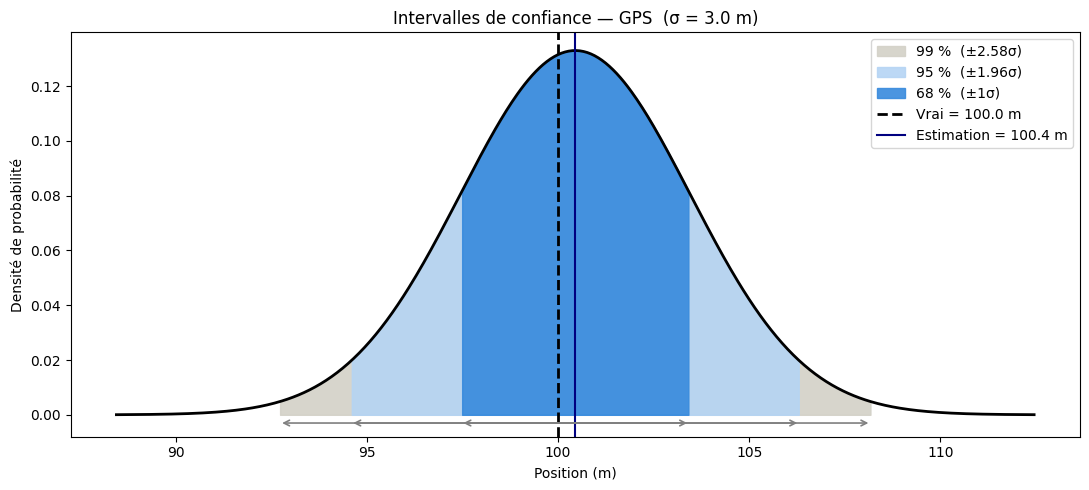

In [15]:
x_range = np.linspace(estimate - 4*gps_sigma, estimate + 4*gps_sigma, 500)
pdf = norm.pdf(x_range, estimate, gps_sigma)

fig, ax = plt.subplots(figsize=(11, 5))

# Remplissages par niveau de confiance
fills = [
    (2.58, '#D3D1C7', '99 %  (±2.58σ)'),
    (1.96, '#B5D4F4', '95 %  (±1.96σ)'),
    (1.00, '#378ADD', '68 %  (±1σ)'),
]
for k, color, label in fills:
    mask = np.abs(x_range - estimate) <= k * gps_sigma
    ax.fill_between(x_range, pdf, where=mask, color=color, alpha=0.9, label=label)

ax.plot(x_range, pdf, 'k-', linewidth=2)
ax.axvline(true_position, color='black', linewidth=2,
           linestyle='--', label=f'Vrai = {true_position} m')
ax.axvline(estimate, color='navy', linewidth=1.5,
           linestyle='-', label=f'Estimation = {estimate:.1f} m')

# Annotations des bornes
for k, _, label in fills:
    lo, hi = estimate - k*gps_sigma, estimate + k*gps_sigma
    ax.annotate('', xy=(hi, -0.003), xytext=(lo, -0.003),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))

ax.set_xlabel('Position (m)')
ax.set_ylabel('Densité de probabilité')
ax.set_title(f'Intervalles de confiance — GPS  (σ = {gps_sigma} m)')
ax.legend(fontsize=10)
ax.set_ylim(bottom=-0.008)
plt.tight_layout()
plt.show()

---
## 4. L'intervalle de confiance sur la moyenne

Jusqu'ici, $\sigma$ désignait l'incertitude **d'une seule mesure**.

Quand on calcule la **moyenne** de $N$ mesures, l'incertitude sur cette moyenne est bien plus faible :

$$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}}$$

C'est pourquoi accumuler des mesures améliore l'estimation — mais avec des **rendements décroissants** :

| N mesures | Incertitude sur la moyenne |
|-----------|---------------------------|
| 1 | $\sigma$ |
| 4 | $\sigma / 2$ |
| 100 | $\sigma / 10$ |
| 10 000 | $\sigma / 100$ |

Pour diviser l'incertitude par 2, il faut **4 fois plus** de mesures.  
Pour diviser par 10, il en faut **100 fois plus**.

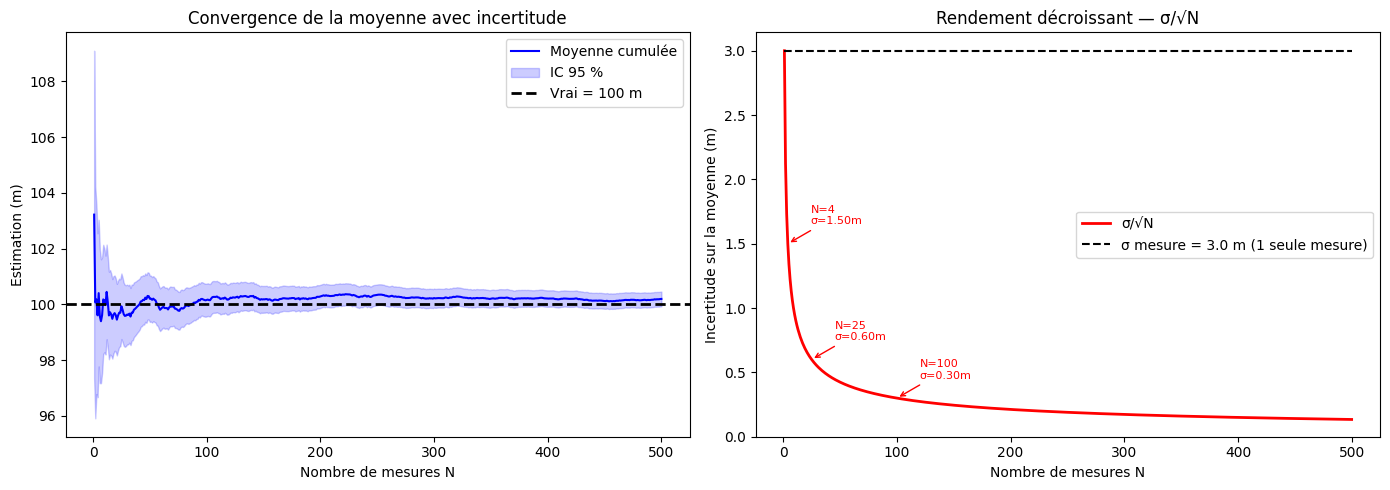

Incertitude sur la moyenne selon N :
  N=   1  →  σ_mean = 3.000 m  (IC 95% = ±5.88 m)
  N=   4  →  σ_mean = 1.500 m  (IC 95% = ±2.94 m)
  N=  10  →  σ_mean = 0.949 m  (IC 95% = ±1.86 m)
  N=  25  →  σ_mean = 0.600 m  (IC 95% = ±1.18 m)
  N= 100  →  σ_mean = 0.300 m  (IC 95% = ±0.59 m)
  N= 500  →  σ_mean = 0.134 m  (IC 95% = ±0.26 m)


In [18]:
gps_sigma = 3.0
N_max = 500
all_measurements = true_position + np.random.normal(0, gps_sigma, N_max)

ns = np.arange(1, N_max + 1)
cumul_mean = np.cumsum(all_measurements) / ns
sigma_mean = gps_sigma / np.sqrt(ns)   # incertitude sur la moyenne

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence avec bande d'incertitude
ax = axes[0]
ax.plot(ns, cumul_mean, 'b-', linewidth=1.5, label='Moyenne cumulée')
ax.fill_between(ns,
                cumul_mean - 1.96 * sigma_mean,
                cumul_mean + 1.96 * sigma_mean,
                alpha=0.2, color='blue', label='IC 95 %')
ax.axhline(true_position, color='black', linewidth=2,
           linestyle='--', label='Vrai = 100 m')
ax.set_xlabel('Nombre de mesures N')
ax.set_ylabel('Estimation (m)')
ax.set_title('Convergence de la moyenne avec incertitude')
ax.legend()

# Décroissance de l'incertitude
ax = axes[1]
ax.plot(ns, sigma_mean, 'r-', linewidth=2, label='σ/√N')
ax.plot(ns, gps_sigma * np.ones_like(ns), 'k--',
        linewidth=1.5, label=f'σ mesure = {gps_sigma} m (1 seule mesure)')
for n_mark in [4, 25, 100]:
    ax.annotate(f'N={n_mark}\nσ={gps_sigma/np.sqrt(n_mark):.2f}m',
                xy=(n_mark, gps_sigma/np.sqrt(n_mark)),
                xytext=(n_mark + 20, gps_sigma/np.sqrt(n_mark) + 0.15),
                fontsize=8, color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=1))
ax.set_xlabel('Nombre de mesures N')
ax.set_ylabel('Incertitude sur la moyenne (m)')
ax.set_title('Rendement décroissant — σ/√N')
ax.legend()
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print("Incertitude sur la moyenne selon N :")
for n in [1, 4, 10, 25, 100, 500]:
    print(f"  N={n:4d}  →  σ_mean = {gps_sigma/np.sqrt(n):.3f} m  "
          f"(IC 95% = ±{1.96*gps_sigma/np.sqrt(n):.2f} m)")

---
## 5. Synthèse — ce que le filtre de Kalman retient de tout ça

Ces trois notions se retrouvent directement dans le filtre de Kalman :

| Notion | Rôle dans le filtre de Kalman |
|--------|------------------------------|
| **Biais** | Le filtre suppose un bruit **non biaisé**. Un biais non corrigé dégradera l'estimation. Pour les IMU, le biais est souvent estimé comme variable d'état supplémentaire. |
| **Précision vs exactitude** | La matrice $R$ encode la **précision** du capteur (variance). Elle ne corrige pas un biais — c'est le rôle de la calibration. |
| **Intervalle de confiance** | La matrice $P$ du filtre représente l'incertitude de l'estimation. À chaque pas, elle donne l'équivalent d'un intervalle de confiance sur l'état estimé. |

---
## Exercices

### Exercice 1 — Détecter un biais

Un capteur produit les mesures suivantes d'une grandeur fixe de valeur inconnue :

```python
mesures = [47.2, 48.1, 47.8, 46.9, 48.3, 47.5, 48.0, 47.7, 48.2, 47.9]
```

Un capteur de référence indique que la vraie valeur est **45.0**.

**Q1 :** Calculez la moyenne et l'écart-type des mesures.  
**Q2 :** Estimez le biais du capteur.  
**Q3 :** Corrigez les mesures en soustrayant le biais estimé et recalculez la moyenne.  
**Q4 :** Tracez l'histogramme avant et après correction.

In [22]:
# Exercice 1
mesures = [47.2, 48.1, 47.8, 46.9, 48.3, 47.5, 48.0, 47.7, 48.2, 47.9]
vraie_valeur = 45.0

# TODO : calculer moyenne, écart-type, biais
# TODO : corriger les mesures
# TODO : tracer histogramme avant/après

### Exercice 2 — Classer quatre capteurs

Quatre capteurs mesurent une distance réelle de **50 m** :

```python
capteur_1 = [50.1, 49.9, 50.2, 50.0, 49.8]   # ?
capteur_2 = [55.1, 54.9, 55.2, 55.0, 54.8]   # ?
capteur_3 = [48.0, 53.0, 47.0, 55.0, 52.0]   # ?
capteur_4 = [43.0, 58.0, 44.0, 57.0, 53.0]   # ?
```

**Q1 :** Pour chaque capteur, calculez la moyenne et l'écart-type.  
**Q2 :** Classez chaque capteur dans l'une des quatre catégories du tableau précision/exactitude.  
**Q3 :** Lequel est le plus dangereux ? Pourquoi ?

In [ ]:
# Exercice 2
vraie_distance = 50.0
capteurs = {
    'Capteur 1': [50.1, 49.9, 50.2, 50.0, 49.8],
    'Capteur 2': [55.1, 54.9, 55.2, 55.0, 54.8],
    'Capteur 3': [48.0, 53.0, 47.0, 55.0, 52.0],
    'Capteur 4': [43.0, 58.0, 44.0, 57.0, 53.0],
}

# TODO : calculer moyenne et écart-type pour chaque capteur
# TODO : classer et justifier

### Exercice 3 — Intervalle de confiance

Un altimètre embarqué mesure l'altitude d'un drone.  
Après 30 mesures, on obtient : moyenne = **142.5 m**, écart-type = **4.0 m**.

**Q1 :** Calculez et interprétez l'intervalle de confiance à 95 %.  
**Q2 :** Un obstacle se trouve à 138 m. Le drone est-il en danger ? Justifiez avec l'intervalle.  
**Q3 :** Combien de mesures faudrait-il pour que l'IC 95 % soit inférieur à ±1 m ?

In [ ]:
# Exercice 3
mean_alt  = 142.5   # m
sigma_alt = 4.0     # m
n_meas    = 30
obstacle  = 138.0   # m

# TODO : calculer IC 95%
# TODO : comparer à la position de l'obstacle
# TODO : trouver N pour IC < ±1 m

---
## Résumé

| Notion | Définition | À retenir |
|--------|-----------|----------|
| **Biais** | Erreur systématique constante | Non corrigeable par la moyenne — nécessite une calibration |
| **Précision** | Mesures groupées entre elles | Liée à $\sigma$ — améliorable par moyennage |
| **Exactitude** | Mesures proches de la vérité | Liée au biais — nécessite une référence externe |
| **IC à 95 %** | Intervalle contenant la vraie valeur avec 95 % de probabilité | $[\hat{x} - 1.96\sigma,\ \hat{x} + 1.96\sigma]$ |
| **σ/√N** | Incertitude sur la moyenne de N mesures | Rendement décroissant — doubler N divise σ par √2 |

---

## Prochaine étape

**Notebook 03 — Inférence bayésienne**  
On va maintenant formaliser la fusion de deux sources d'information avec le théorème de Bayes —  
la fondation mathématique du filtre de Kalman.